# Analise de abstenção do 2º dia do enem
Utilizando algoritmos clássicos de machine learning para tentar prever a abstenção dos alunos no 2º dia do Exanme Nacional do Ensino Médio (ENEM).

Estamos utilizando os dados do ano de `2022` para treino e `2023` para testes. Esses dados podem ser encontrados no site de [dados aberto](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem) do governo

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Dados que serão utilizados

- SG_UF_PROVA (Sigla do estado da prova)
- TP_SEXO (sexo)
- TP_FAIXA_ETARIA (Faixa etaria)
- TP_ESTADO_CIVIL (Estado Civil)
- TP_COR_RACA (Raça)
- TP_ENSINO (ensino regular, EJA...)
- IN_TREINEIRO (Treineiro)
- TP_LOCALIZACAO_ESC (escola rural ou urbana)
- TP_LINGUA (Lingua)

- Redação
    - NU_NOTA_COMP1
    - NU_NOTA_COMP2
    - NU_NOTA_COMP3
    - NU_NOTA_COMP4
    - NU_NOTA_COMP5
    - NU_NOTA_REDACAO

- 1º Dia: Liguagens, humanas e Redação
    - TP_PRESENCA_CH = Ciências humanas
    - TP_PRESENCA_LC = Liguagens e códigos

- 2º Dia: exatas e natureza
    - TP_PRESENCA_MT = Matemática e tecnologias
    - TP_PRESENCA_CN = Ciências da natureza

In [2]:
colunas_selecionadas = [
    'SG_UF_PROVA',
    'TP_SEXO',
    'TP_FAIXA_ETARIA',
    'TP_ESTADO_CIVIL'
    'TP_COR_RACA',
    'TP_ENSINO',
    'IN_TREINEIRO',
    'TP_LOCALIZACAO_ESC',
    'TP_LINGUA',
    'NU_NOTA_COMP1',
    'NU_NOTA_COMP2',
    'NU_NOTA_COMP3',
    'NU_NOTA_COMP4',
    'NU_NOTA_COMP5',
    'NU_NOTA_REDACAO',
    'TP_PRESENCA_CH',
    'TP_PRESENCA_LC',
    'TP_PRESENCA_MT',
    'TP_PRESENCA_CN'
]

## Limpando dados do enem 2022

In [3]:
microdados_enem2022 = pd.read_csv('enem2022/DADOS/MICRODADOS_ENEM_2022.csv', sep=';', encoding='ISO-8859-1', nrows=1000000)

In [4]:
microdados_enem2022.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,210057943671,2022,14,M,2,2,1,1,2,1,...,B,A,A,A,A,A,A,A,A,A
1,210057516120,2022,14,M,2,1,1,1,16,1,...,E,E,B,E,B,B,E,B,E,B
2,210057280536,2022,5,F,1,2,1,1,2,1,...,A,A,A,A,A,A,C,A,A,B
3,210055724397,2022,6,M,1,3,1,1,2,1,...,B,A,A,C,A,A,C,B,B,B
4,210055097896,2022,4,M,0,3,1,1,1,1,...,A,A,A,A,A,A,B,A,A,A


In [5]:
microdados_enem2022.columns.values

<ArrowStringArray>
[          'NU_INSCRICAO',                 'NU_ANO',        'TP_FAIXA_ETARIA',
                'TP_SEXO',        'TP_ESTADO_CIVIL',            'TP_COR_RACA',
       'TP_NACIONALIDADE',        'TP_ST_CONCLUSAO',        'TP_ANO_CONCLUIU',
              'TP_ESCOLA',              'TP_ENSINO',           'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC',       'NO_MUNICIPIO_ESC',              'CO_UF_ESC',
              'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',     'TP_LOCALIZACAO_ESC',
        'TP_SIT_FUNC_ESC',     'CO_MUNICIPIO_PROVA',     'NO_MUNICIPIO_PROVA',
            'CO_UF_PROVA',            'SG_UF_PROVA',         'TP_PRESENCA_CN',
         'TP_PRESENCA_CH',         'TP_PRESENCA_LC',         'TP_PRESENCA_MT',
            'CO_PROVA_CN',            'CO_PROVA_CH',            'CO_PROVA_LC',
            'CO_PROVA_MT',             'NU_NOTA_CN',             'NU_NOTA_CH',
             'NU_NOTA_LC',             'NU_NOTA_MT',        'TX_RESPOSTAS_CN',
        'TX_RESPOSTAS_CH',       

- Filtrando apenas com as colunas selecionadas

In [6]:
dados_enem2022 = microdados_enem2022.filter(colunas_selecionadas)

In [7]:
dados_enem2022.head()

,SG_UF_PROVA,TP_SEXO,TP_FAIXA_ETARIA,TP_ENSINO,IN_TREINEIRO,TP_LOCALIZACAO_ESC,TP_LINGUA,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,TP_PRESENCA_CN
0,DF,M,14,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
1,DF,M,14,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
2,BA,F,5,NaN,0,NaN,1,140.0,200.0,120.0,140.0,160.0,760.0,1,1,1,1
3,ES,M,6,NaN,0,NaN,1,120.0,40.0,40.0,100.0,20.0,320.0,1,1,1,1
4,PA,M,4,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


- Removendo valores nulos

In [8]:
dados_enem2022 = dados_enem2022.dropna()

- Filtrando apenas por alunos de `PE`

In [9]:
dados_enem2022 = dados_enem2022[dados_enem2022['SG_UF_PROVA'] == 'PE']

- Criando a coluna `Dia 1` verificando se houver a presença em `TP_PRESENCA_CH`e `TP_PRESENCA_LC`

In [10]:
dados_enem2022['dia_1'] = np.where(
    (dados_enem2022['TP_PRESENCA_CH'] == 1) & (dados_enem2022['TP_PRESENCA_LC'] == 1), 1, 0
    )

- Criando a coluna `Dia 2` verificando se houver a presença em `TP_PRESENCA_CN`e `TP_PRESENCA_MT`

In [11]:
dados_enem2022['dia_2'] = np.where(
    (dados_enem2022['TP_PRESENCA_CN'] == 1) & (dados_enem2022['TP_PRESENCA_MT'] == 1), 1, 0
    )

- Removendo as colunas `TP_PRESENCA_CH`, `TP_PRESENCA_LC`, `TP_PRESENCA_CN`, `TP_PRESENCA_MT`

In [12]:
colunas_remover = ['TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT']

dados_enem2022 = dados_enem2022.drop(columns=colunas_remover)

- Renomeando colunas

In [13]:
nomes_colunas = {
    'SG_UF_PROVA': 'uf_prova',
    'TP_SEXO': 'sexo',
    'TP_FAIXA_ETARIA': 'faixa_etaria',
    'TP_ENSINO': 'tipo_ensino',
    'IN_TREINEIRO': 'treineiro',
    'TP_LOCALIZACAO_ESC': 'localizacao_escola',
    'TP_LINGUA': 'lingua_estrangeira',
    'NU_NOTA_COMP1': 'nota_competencia_1',
    'NU_NOTA_COMP2': 'nota_competencia_2',
    'NU_NOTA_COMP3': 'nota_competencia_3',
    'NU_NOTA_COMP4': 'nota_competencia_4',
    'NU_NOTA_COMP5': 'nota_competencia_5',
    'NU_NOTA_REDACAO': 'nota_redacao',
    'dia_1': 'presenca_dia_1',
    'dia_2': 'presenca_dia_2'
}

In [14]:
dados_enem2022 = dados_enem2022.rename(columns=nomes_colunas)

- Convertendo os dados da coluna `sexo` para inteiro
    - F = 0
    - M = 1

In [15]:
dados_enem2022['sexo'] = dados_enem2022['sexo'].replace({'F': 0, 'M': 1})

In [16]:
dados_enem2022.sample(5)

,uf_prova,sexo,faixa_etaria,tipo_ensino,treineiro,localizacao_escola,lingua_estrangeira,nota_competencia_1,nota_competencia_2,nota_competencia_3,nota_competencia_4,nota_competencia_5,nota_redacao,presenca_dia_1,presenca_dia_2
395456,PE,0,3,1.0,0,1.0,1,160.0,200.0,160.0,140.0,180.0,840.0,1,1
678502,PE,1,3,1.0,0,1.0,0,160.0,200.0,160.0,160.0,200.0,880.0,1,1
853906,PE,1,2,1.0,0,1.0,0,120.0,160.0,120.0,160.0,160.0,720.0,1,1
626975,PE,0,2,1.0,0,1.0,1,140.0,200.0,120.0,140.0,160.0,760.0,1,1
981003,PE,0,2,2.0,0,1.0,0,120.0,160.0,120.0,160.0,120.0,680.0,1,1


- Salvando em csv

In [17]:
dados_enem2022.to_csv('dados_enem2022.csv', index=False)

## Limpando dados do enem 2023

In [18]:
microdados_enem2023 = pd.read_csv('enem2023/DADOS/MICRODADOS_ENEM_2023.csv', sep=';', encoding='ISO-8859-1', nrows=1000000)

In [19]:
microdados_enem2023.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,210059085136,2023,14,M,2,1,1,1,17,1,...,C,C,B,B,A,B,B,A,A,B
1,210059527735,2023,12,M,2,1,0,1,16,1,...,B,A,B,B,A,A,C,A,D,B
2,210061103945,2023,6,F,1,1,1,1,0,1,...,B,A,A,B,A,A,A,A,A,B
3,210060214087,2023,2,F,1,3,1,2,0,2,...,A,A,A,B,A,A,D,A,A,B
4,210059980948,2023,3,F,1,3,1,2,0,2,...,A,A,A,B,A,A,B,A,A,A


In [20]:
microdados_enem2023.columns.values

<ArrowStringArray>
[          'NU_INSCRICAO',                 'NU_ANO',        'TP_FAIXA_ETARIA',
                'TP_SEXO',        'TP_ESTADO_CIVIL',            'TP_COR_RACA',
       'TP_NACIONALIDADE',        'TP_ST_CONCLUSAO',        'TP_ANO_CONCLUIU',
              'TP_ESCOLA',              'TP_ENSINO',           'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC',       'NO_MUNICIPIO_ESC',              'CO_UF_ESC',
              'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',     'TP_LOCALIZACAO_ESC',
        'TP_SIT_FUNC_ESC',     'CO_MUNICIPIO_PROVA',     'NO_MUNICIPIO_PROVA',
            'CO_UF_PROVA',            'SG_UF_PROVA',         'TP_PRESENCA_CN',
         'TP_PRESENCA_CH',         'TP_PRESENCA_LC',         'TP_PRESENCA_MT',
            'CO_PROVA_CN',            'CO_PROVA_CH',            'CO_PROVA_LC',
            'CO_PROVA_MT',             'NU_NOTA_CN',             'NU_NOTA_CH',
             'NU_NOTA_LC',             'NU_NOTA_MT',        'TX_RESPOSTAS_CN',
        'TX_RESPOSTAS_CH',       

- Filtrando apenas colunas selecionadas

In [21]:
dados_enem2023 = microdados_enem2023.filter(colunas_selecionadas)

- Removendo dados nulos

In [22]:
dados_enem2023 = dados_enem2023.dropna()

- Filtrado por alunos do estado de `PE`

In [23]:
dados_enem2023 = dados_enem2023[dados_enem2023['SG_UF_PROVA'] == 'PE']

- Criando a coluna `Dia 1` verificando se houver a presença em `TP_PRESENCA_CH`e `TP_PRESENCA_LC`

In [24]:
dados_enem2023['dia_1'] = np.where(
    (dados_enem2023['TP_PRESENCA_CH'] == 1) & (dados_enem2023['TP_PRESENCA_LC'] == 1), 1, 0
    )

- Criando a coluna `Dia 2` verificando se houver a presença em `TP_PRESENCA_CN`e `TP_PRESENCA_MT`

In [25]:
dados_enem2023['dia_2'] = np.where(
    (dados_enem2023['TP_PRESENCA_CN'] == 1) & (dados_enem2023['TP_PRESENCA_MT'] == 1), 1, 0
    )

- Removendo as colunas `TP_PRESENCA_CH`, `TP_PRESENCA_LC`, `TP_PRESENCA_CN`, `TP_PRESENCA_MT`

In [26]:
dados_enem2023 = dados_enem2023.drop(columns=colunas_remover)

- Renomeando colunas

In [27]:
dados_enem2023 = dados_enem2023.rename(columns=nomes_colunas)

- Convertendo os dados da coluna `sexo` para inteiro
    - F = 0
    - M = 1

In [28]:
dados_enem2023['sexo'] = dados_enem2023['sexo'].replace({'F': 0, 'M': 1})

In [29]:
dados_enem2023.sample(5)

,uf_prova,sexo,faixa_etaria,tipo_ensino,treineiro,localizacao_escola,lingua_estrangeira,nota_competencia_1,nota_competencia_2,nota_competencia_3,nota_competencia_4,nota_competencia_5,nota_redacao,presenca_dia_1,presenca_dia_2
696303,PE,1,3,1.0,0,1.0,1,120.0,140.0,120.0,120.0,100.0,600.0,1,1
754587,PE,1,4,1.0,0,1.0,0,120.0,160.0,120.0,120.0,120.0,640.0,1,1
797341,PE,0,4,1.0,0,1.0,1,80.0,180.0,100.0,120.0,100.0,580.0,1,1
693147,PE,1,2,1.0,0,1.0,0,100.0,140.0,100.0,100.0,40.0,480.0,1,1
497898,PE,0,3,1.0,0,1.0,1,120.0,140.0,100.0,120.0,120.0,600.0,1,1


- Salvando em csv

In [30]:
dados_enem2023.to_csv('dados_enem2023.csv', index=False)

## Comparando 2022 e 2023

In [31]:
dados_enem2023.sample(1)

,uf_prova,sexo,faixa_etaria,tipo_ensino,treineiro,localizacao_escola,lingua_estrangeira,nota_competencia_1,nota_competencia_2,nota_competencia_3,nota_competencia_4,nota_competencia_5,nota_redacao,presenca_dia_1,presenca_dia_2
644392,PE,0,2,1.0,0,1.0,0,160.0,200.0,160.0,160.0,180.0,860.0,1,1


In [32]:
dados_enem2022.sample(1)

,uf_prova,sexo,faixa_etaria,tipo_ensino,treineiro,localizacao_escola,lingua_estrangeira,nota_competencia_1,nota_competencia_2,nota_competencia_3,nota_competencia_4,nota_competencia_5,nota_redacao,presenca_dia_1,presenca_dia_2
788053,PE,0,3,1.0,0,1.0,0,140.0,200.0,160.0,160.0,200.0,860.0,1,1


In [33]:
dados_enem2022.columns

Index(['uf_prova', 'sexo', 'faixa_etaria', 'tipo_ensino', 'treineiro',
       'localizacao_escola', 'lingua_estrangeira', 'nota_competencia_1',
       'nota_competencia_2', 'nota_competencia_3', 'nota_competencia_4',
       'nota_competencia_5', 'nota_redacao', 'presenca_dia_1',
       'presenca_dia_2'],
      dtype='str')

## Naive Bayes

In [34]:
atributos = ['sexo', 'faixa_etaria', 'tipo_ensino', 'localizacao_escola', 'lingua_estrangeira', 'nota_competencia_1', 'nota_competencia_2', 'nota_competencia_3', 'nota_competencia_4', 'nota_competencia_5', 'nota_redacao']

In [35]:
# Dados de Treino (2022)
X_train = dados_enem2022[atributos]
y_train = dados_enem2022['presenca_dia_2']  # Seu alvo (se compareceu ou não)

# Dados de Teste (2023)
X_test = dados_enem2023[atributos]
y_test = dados_enem2023['presenca_dia_2']

In [36]:
# Inicializa o modelo
modelo_nb = GaussianNB()

# Treina a IA com os dados de 2022
modelo_nb.fit(X_train, y_train)

# Faz as previsões para os alunos de 2023
previsoes_nb = modelo_nb.predict(X_test)

In [37]:
print(f"Acurácia Geral: {accuracy_score(y_test, previsoes_nb) * 100:.2f}%")
print("\nRelatório de Classificação:")
print(classification_report(y_test, previsoes_nb))

Acurácia Geral: 91.66%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.12      0.38      0.18       253
           1       0.98      0.93      0.96     10519

    accuracy                           0.92     10772
   macro avg       0.55      0.66      0.57     10772
weighted avg       0.96      0.92      0.94     10772



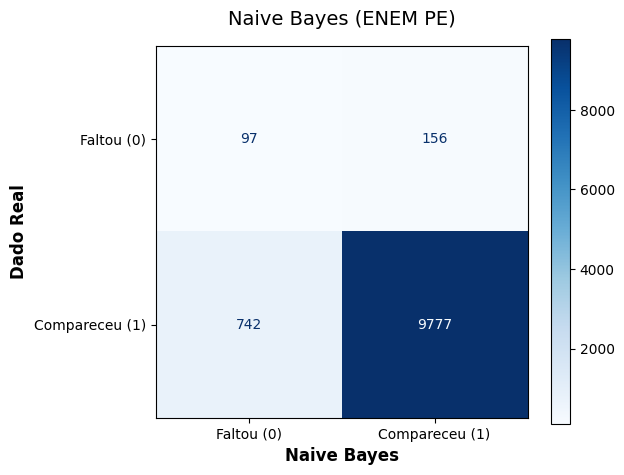

In [38]:
matriz = confusion_matrix(y_test, previsoes_nb)

disparar_grafico = ConfusionMatrixDisplay(
    confusion_matrix=matriz, 
    display_labels=['Faltou (0)', 'Compareceu (1)']
)

fig, ax = plt.subplots(figsize=(6, 5))
disparar_grafico.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_xlabel('Naive Bayes', fontsize=12, fontweight='bold')
ax.set_ylabel('Dado Real', fontsize=12, fontweight='bold')
plt.title('Naive Bayes (ENEM PE)', fontsize=14, pad=15)

plt.show()

In [39]:
dados_enem2023.shape

(10772, 15)

In [40]:
dados_enem2022['presenca_dia_2'].value_counts()

presenca_dia_2
1    9397
0     361
Name: count, dtype: int64

## Árvore de Decisão

## KNN